# Introduction

The purpose of this notebook is to perform a binary classification of network intrusion from the KDD Cup 1999 dataset utilizing various machine learning algorithms.

# Data exploration and Preparation

The dataset is loaded using pandas from its CSV file location and columns are renamed for clarity

In [53]:
#Read data
import pandas as pd
df = pd.read_csv("~\Downloads\kddcup.data_10_percent\kddcup.data_10_percent_corrected.csv")

In [54]:
#Rename Columns
df.columns = [
    'duration',
    'protocol_type',
    'service',
    'flag',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_count',
    'dst_host_srv_count',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'outcome'
]

df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,494020.000000,4.940200e+05,4.940200e+05,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,...,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000
mean,47.979400,3.025616e+03,8.685232e+02,0.000045,0.006433,0.000014,0.034519,0.000152,0.148245,0.010212,...,232.471230,188.666034,0.753779,0.030906,0.601936,0.006684,0.176754,0.176443,0.058118,0.057412
std,707.747185,9.882191e+05,3.304003e+04,0.006673,0.134805,0.005510,0.782103,0.015520,0.355343,1.798328,...,64.744665,106.040236,0.410781,0.109259,0.481309,0.042133,0.380593,0.380920,0.230590,0.230141
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,46.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [55]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal.
1,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal.
2,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal.
3,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,59,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,0,tcp,http,SF,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal.
494016,0,tcp,http,SF,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal.
494017,0,tcp,http,SF,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal.
494018,0,tcp,http,SF,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal.


# Data Preprocessing

This section of the notebook prepares the dataset for machine learning by standardizing and encoding the data appropriately, eliminating redundancy, and ensuring data integrity.

In [56]:
cols = df.columns

Preprocessing functions are written to normalize numerical features to have a mean of zero and standard deviation of one as well as encoded categorical text features into numerical repressentations with OrdinalEncoder.

In [57]:
# Encode a numeric column as zscores
def zscore_normalization(df, name, mean=None, sd=None):
    if mean is None:
        mean = df[name].mean()

    if sd is None:
        sd = df[name].std()

    df[name] = (df[name] - mean) / sd

from sklearn.preprocessing import OrdinalEncoder
def encode_text(df, name):
    enc = OrdinalEncoder()
    # dummies = pd.get_dummies(df[name])
    # Fit and transform name column to ordinal integers
    data = enc.fit_transform(df[name].values.reshape(-1,1))
    # Replace the original name column with transformed values 
    df[name]=data.flatten()

Preprocessing functions are applied to relevant columns, preparing them for modeling.

In [58]:
zscore_normalization(df, 'duration')
encode_text(df, 'protocol_type')
encode_text(df, 'service')
encode_text(df, 'flag')
zscore_normalization(df, 'src_bytes')
zscore_normalization(df, 'dst_bytes')
encode_text(df, 'land')
zscore_normalization(df, 'wrong_fragment')
zscore_normalization(df, 'urgent')
zscore_normalization(df, 'hot')
zscore_normalization(df, 'num_failed_logins')
encode_text(df, 'logged_in')
zscore_normalization(df, 'num_compromised')
zscore_normalization(df, 'root_shell')
zscore_normalization(df, 'su_attempted')
zscore_normalization(df, 'num_root')
zscore_normalization(df, 'num_file_creations')
zscore_normalization(df, 'num_shells')
zscore_normalization(df, 'num_access_files')
zscore_normalization(df, 'num_outbound_cmds')
encode_text(df, 'is_host_login')
encode_text(df, 'is_guest_login')
zscore_normalization(df, 'count')
zscore_normalization(df, 'srv_count')
zscore_normalization(df, 'serror_rate')
zscore_normalization(df, 'srv_serror_rate')
zscore_normalization(df, 'rerror_rate')
zscore_normalization(df, 'srv_rerror_rate')
zscore_normalization(df, 'same_srv_rate')
zscore_normalization(df, 'diff_srv_rate')
zscore_normalization(df, 'srv_diff_host_rate')
zscore_normalization(df, 'dst_host_count')
zscore_normalization(df, 'dst_host_srv_count')
zscore_normalization(df, 'dst_host_same_srv_rate')
zscore_normalization(df, 'dst_host_diff_srv_rate')
zscore_normalization(df, 'dst_host_same_src_port_rate')
zscore_normalization(df, 'dst_host_srv_diff_host_rate')
zscore_normalization(df, 'dst_host_serror_rate')
zscore_normalization(df, 'dst_host_srv_serror_rate')
zscore_normalization(df, 'dst_host_rerror_rate')
zscore_normalization(df, 'dst_host_srv_rerror_rate')

# Handles NA values
df.dropna(inplace=True,axis=1)

Redundant columns are handled in the dataframe.

In [59]:
df = df.loc[:, df.nunique() != 1]

In [60]:
len(df.columns)

40

In [96]:
print(len(cols))
print(len(df.columns))
for col in cols:
    if col not in df.columns:
        print(col)

42
21
duration
service
src_bytes
land
urgent
num_failed_logins
num_compromised
su_attempted
num_file_creations
num_access_files
num_outbound_cmds
is_host_login
count
serror_rate
rerror_rate
same_srv_rate
srv_diff_host_rate
dst_host_srv_count
dst_host_diff_srv_rate
dst_host_srv_diff_host_rate
dst_host_srv_serror_rate


In [62]:
df["outcome"].value_counts()

outcome
smurf.              280790
neptune.            107201
normal.              97277
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
phf.                     4
perl.                    3
spy.                     2
Name: count, dtype: int64

Encoding the outcomes into binary representations for abnormal and normal outcomes, ensuring binary classification

In [63]:
df.loc[df['outcome'] != "normal.", 'outcome']  = 1
df.loc[df['outcome'] == "normal.", 'outcome']  = 0

In [64]:
df["outcome"].value_counts()

outcome
1    396743
0     97277
Name: count, dtype: int64

In [65]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,-0.067792,1.0,22.0,9.0,-0.002820,-0.011578,0.0,-0.04772,-0.002571,-0.044136,...,-1.600016,0.599396,-0.282867,-1.146738,-0.158629,-0.464418,-0.463202,-0.25204,-0.249464,0
1,-0.067792,1.0,22.0,9.0,-0.002824,0.014179,0.0,-0.04772,-0.002571,-0.044136,...,-1.505712,0.599396,-0.282867,-1.188292,-0.158629,-0.464418,-0.463202,-0.25204,-0.249464,0
2,-0.067792,1.0,22.0,9.0,-0.002840,0.014179,0.0,-0.04772,-0.002571,-0.044136,...,-1.411408,0.599396,-0.282867,-1.188292,-0.158629,-0.464418,-0.463202,-0.25204,-0.249464,0
3,-0.067792,1.0,22.0,9.0,-0.002842,0.035214,0.0,-0.04772,-0.002571,-0.044136,...,-1.317104,0.599396,-0.282867,-1.209068,-0.158629,-0.464418,-0.463202,-0.25204,-0.249464,0
4,-0.067792,1.0,22.0,9.0,-0.002842,0.035214,0.0,-0.04772,-0.002571,-0.044136,...,-1.222800,0.599396,-0.282867,-1.209068,-0.158629,-0.464418,-0.463202,-0.25204,-0.249464,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,-0.067792,1.0,22.0,9.0,-0.002748,0.030644,0.0,-0.04772,-0.002571,-0.044136,...,0.625555,0.599396,-0.282867,-1.229845,1.028091,-0.464418,-0.436950,-0.25204,-0.249464,0
494016,-0.067792,1.0,22.0,9.0,-0.002776,0.042902,0.0,-0.04772,-0.002571,-0.044136,...,0.625555,0.599396,-0.282867,-0.897418,1.028091,-0.464418,-0.436950,-0.25204,-0.249464,0
494017,-0.067792,1.0,22.0,9.0,-0.002856,0.010033,0.0,-0.04772,-0.002571,-0.044136,...,0.625555,0.599396,-0.282867,-1.125962,1.028091,-0.306769,-0.436950,-0.25204,-0.249464,0
494018,-0.067792,1.0,22.0,9.0,-0.002767,0.010033,0.0,-0.04772,-0.002571,-0.044136,...,0.625555,0.599396,-0.282867,-1.167515,1.028091,-0.359319,-0.436950,-0.25204,-0.249464,0


In [66]:
df2 = df
encode_text(df, 'outcome')

C:\Users\SachinAshok\AppData\Local\Temp\ipykernel_8560\2122246776.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[name]=data.flatten()


# Feature Engineering

This section aims to identify and eliminate features that have little correlation on outcome, increasing model performance.

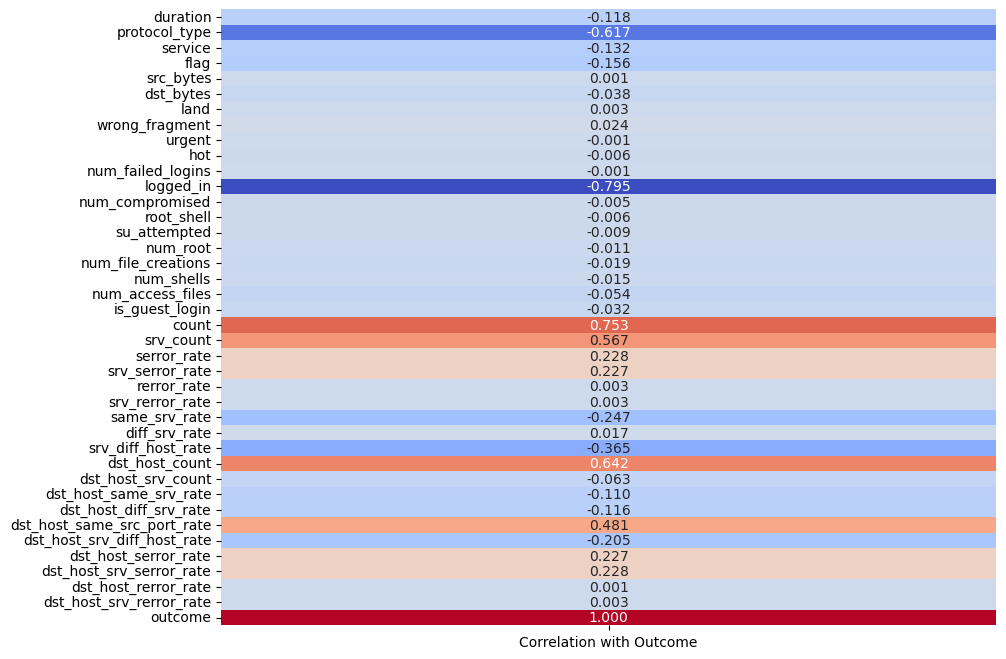

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation
correlation = df2.corrwith(df2['outcome'])

# Create a DataFrame from the correlation results
correlation_df = pd.DataFrame(correlation, columns=['Correlation with Outcome'])

# Set the figure size
plt.figure(figsize=(10, 8))

# Create a heatmap
heatmap = sns.heatmap(correlation_df, annot=True, cmap='coolwarm', fmt=".3f", cbar=False)

# Set the rotation of the y-axis labels
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0)

# Display the plot
plt.show()


In [70]:
correlation

duration                      -0.118015
protocol_type                 -0.616600
service                       -0.131724
flag                          -0.155671
src_bytes                      0.000936
dst_bytes                     -0.037709
land                           0.002542
wrong_fragment                 0.023629
urgent                        -0.001498
hot                           -0.006327
num_failed_logins             -0.001060
logged_in                     -0.795280
num_compromised               -0.005046
root_shell                    -0.005871
su_attempted                  -0.008789
num_root                      -0.011006
num_file_creations            -0.018671
num_shells                    -0.014951
num_access_files              -0.054268
is_guest_login                -0.032300
count                          0.752977
srv_count                      0.566828
serror_rate                    0.227739
srv_serror_rate                0.227188
rerror_rate                    0.003189


Features with outcome correlations lower than 0.01 are eliminated from the dataset

In [71]:
row = 0
for num in correlation:
 if num >= -0.05 and num <= 0.05:
     df.drop(df.columns[row], axis=1, inplace=True)
     row += 1

C:\Users\SachinAshok\AppData\Local\Temp\ipykernel_8560\3308703655.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(df.columns[row], axis=1, inplace=True)
C:\Users\SachinAshok\AppData\Local\Temp\ipykernel_8560\3308703655.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(df.columns[row], axis=1, inplace=True)
C:\Users\SachinAshok\AppData\Local\Temp\ipykernel_8560\3308703655.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-

In [73]:
df2

,protocol_type,flag,dst_bytes,wrong_fragment,hot,logged_in,root_shell,num_root,num_shells,is_guest_login,...,srv_serror_rate,srv_rerror_rate,diff_srv_rate,dst_host_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,1.0,9.0,-0.011578,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-3.297125,0.599396,-1.146738,-0.464418,-0.25204,-0.249464,0.0
1,1.0,9.0,0.014179,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-3.142672,0.599396,-1.188292,-0.464418,-0.25204,-0.249464,0.0
2,1.0,9.0,0.014179,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-2.988219,0.599396,-1.188292,-0.464418,-0.25204,-0.249464,0.0
3,1.0,9.0,0.035214,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-2.833766,0.599396,-1.209068,-0.464418,-0.25204,-0.249464,0.0
4,1.0,9.0,0.035214,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-2.679313,0.599396,-1.209068,-0.464418,-0.25204,-0.249464,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,1.0,9.0,0.030644,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-2.262290,0.599396,-1.229845,-0.464418,-0.25204,-0.249464,0.0
494016,1.0,9.0,0.042902,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-3.497913,0.599396,-0.897418,-0.464418,-0.25204,-0.249464,0.0
494017,1.0,9.0,0.010033,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.174819,-0.248631,-0.255243,-3.343460,0.599396,-1.125962,-0.306769,-0.25204,-0.249464,0.0
494018,1.0,9.0,0.010033,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-3.189008,0.599396,-1.167515,-0.359319,-0.25204,-0.249464,0.0


In [74]:
df=df2
df["outcome"].value_counts()

outcome
1.0    396743
0.0     97277
Name: count, dtype: int64

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

In [76]:
X = df.drop(columns=["outcome"])
y = df["outcome"]

# Data Splitting

The dataset is split into training and validation sets

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model Training

This section focuses on selecting and implementing appropriate models, training them on the preprocessed dataset, and producing evaluation metrics.

### Random Forest Classifier

The Random Forest Classifier is chosen and trained on the training data to learn patterns utlizing the sklearn.ensemble library, producing metrics for excecution time and model accuracy.

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import timeit

# Start the timer for training
start_train = timeit.default_timer()

# Create and train the model
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

# Stop the timer for training
end_train = timeit.default_timer()

# Print the training time
print(f"Training Time: {end_train - start_train} seconds")

# Start the timer for testing
start_test = timeit.default_timer()

# Make predictions
y_pred2 = rfc.predict(X_test)

# Stop the timer for testing
end_test = timeit.default_timer()

# Print the testing time
print(f"Testing Time: {end_test - start_test} seconds")

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred2)
print(f"Accuracy: {accuracy}")


Training Time: 9.079252700088546 seconds
Testing Time: 0.4115205998532474 seconds
Accuracy: 0.9995951580907656


# RFC Cross Validation

Applies Cross Validation on the RFC using the entire dataset with ten folds, ouputting accuracy on each individual fold

In [79]:
#Cross Validation
from sklearn.model_selection import cross_val_score
cross_val_score(rfc, X, y, cv=10)

array([0.99176147, 0.97825999, 0.99987855, 0.99979758, 0.99973685,
       0.99989879, 0.99967613, 0.99955467, 0.9992308 , 0.99817821])

# Visualizing Feature Importance

Visualizes relative features of RFC to perform further feature engineering.

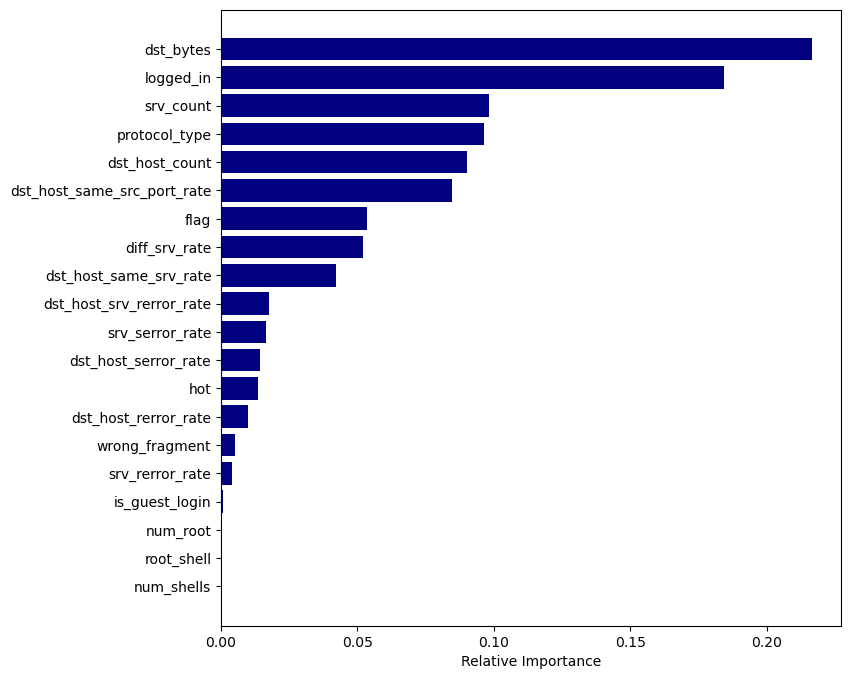

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the feature importances
sorted_indices = np.argsort(rfc.feature_importances_)

# Create a range for the y-axis
y_ticks = np.arange(0, len(i))

# Create a horizontal bar plot with color mapping
plt.figure(figsize=(8, 8))
plt.barh(y_ticks, importances[sorted_indices], align='center', color='navy')
plt.yticks(y_ticks, [df.columns[j] for j in sorted_indices])
plt.xlabel('Relative Importance')

# Show the plot
plt.show()


### Decision Trees

The Decision Tree Classifier is chosen and trained on the training data to learn patterns utlizing the sklearn.ensemble library, producing metrics for excecution time and model accuracy.

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time

# Create and train the model
dtc = DecisionTreeClassifier()

start_train = time.time()
dtc.fit(X_train, y_train)
end_train = time.time()

# Print the training time
print(f"Training Time: {end_train - start_train} seconds")

# Make predictions
start_test = time.time()
y_pred3 = dtc.predict(X_test)
end_test = time.time()

# Print the testing time
print(f"Testing Time: {end_test - start_test} seconds")

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred3)
print(f"Accuracy: {accuracy}")


Training Time: 0.5496106147766113 seconds
Testing Time: 0.015630483627319336 seconds
Accuracy: 0.999342131897494


### SVM

The SVM is chosen and trained on the training data to learn patterns utlizing the sklearn.ensemble library, producing metrics for excecution time and model accuracy.

In [94]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

# Create and train the model
svc = SVC()

start_train = time.time()
svc.fit(X_train, y_train)
end_train = time.time()

# Print the training time
print(f"Training Time: {end_train - start_train} seconds")

# Make predictions
start_test = time.time()
y_pred4 = svc.predict(X_test)
end_test = time.time()

# Print the testing time
print(f"Testing Time: {end_test - start_test} seconds")

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred4)
print(f"Accuracy: {accuracy}")


Training Time: {end_train - start_train} seconds
Testing Time: 16.511286973953247 seconds
Accuracy: 0.9967815068215862


In [105]:
num_features = df.shape[1]
print(f"The dataframe has {num_features} features.")

The dataframe has 21 features.


### Artifical neural network

In [102]:
!conda install tensorflow

Channels:
 - defaults
Platform: win-64


Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)'))': /pkgs/main/win-64/repodata.json.zst

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)'))': /pkgs/r/win-64/repodata.json.zst

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)'))': /pkgs/main/noarch/repodata.json.zst

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken 

In [100]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the model
model = Sequential()
model.add(Dense(21, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')


ModuleNotFoundError: No module named 'tensorflow'

### Isolation Forest

The Isolation Forest is chosen and trained on the training data to learn patterns utlizing the sklearn.ensemble library, producing metrics for excecution time and model accuracy.